# Pure CNN Implementation for Book Pose Classification
**Author**: Assistant
**Task**: Classify book poses (`book`, `reverse`, `backward`, `flat`) using a custom CNN from scratch (Pure CNN).
**Constraint**: No Transfer Learning, No Attention, Custom Architecture.



In [1]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Configuration
# Assuming notebook is running in pure_cnn/ directory
ROOT_DIR = r"../" 
DATA_DIR = os.path.join(ROOT_DIR, "dataset/for_purecnn/2.v3i.voc")
MODEL_SAVE_PATH = "best_model.pth"

# Hyperparameters
BATCH_SIZE = 16  # Smaller batch size for 512x512 images to avoid OOM
LEARNING_RATE = 0.001
NUM_EPOCHS = 20
IMG_SIZE = 512
SEED = 42

# Device Configuration (GPU Acceleration)
# Check for GPU and enable it if available
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print(f"✅ GPU Acceleration Enabled: {torch.cuda.get_device_name(0)}")
    print(f"   VRAM allocated: {torch.cuda.memory_allocated(0)/1024**3:.2f} GB")
else:
    DEVICE = torch.device("cpu")
    print("⚠️ No GPU detected. Using CPU. Training will be slower.")

print(f"Using device: {DEVICE}")

# Set Random Seed for Reproducibility
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(SEED)


✅ GPU Acceleration Enabled: NVIDIA GeForce RTX 3060 Laptop GPU
   VRAM allocated: 0.00 GB
Using device: cuda


In [2]:
# Custom Dataset Class with Object Cropping
class VOCDataset(Dataset):
    def __init__(self, root_dir, split='train', transform=None):
        """
        Args:
            root_dir (string): Path to the dataset root.
            split (string): 'train', 'valid', or 'test'.
            transform (callable, optional): Transform to be applied on a sample.
        
        Improvement:
        This dataset parses XML files to extract INDIVIDUAL objects using their bounding boxes.
        If an image contains multiple books (objects), each one is cropped and treated as 
        a separate training sample. This reduces background noise and solves the multi-label issue.
        """
        self.split_dir = os.path.join(root_dir, split)
        self.transform = transform
        
        # Hardcoded classes
        self.classes = ['backward', 'book', 'flat', 'reverse']
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}
        
        # Store samples as (image_path, label_index, bbox_tuple)
        self.samples = []
        
        print(f"Scanning {split} data for objects...")
        
        # List all XML files
        if not os.path.exists(self.split_dir):
            print(f"Warning: Directory {self.split_dir} does not exist.")
            self.xml_files = []
        else:
            self.xml_files = [f for f in os.listdir(self.split_dir) if f.endswith('.xml')]
        
        for xml_file in self.xml_files:
            xml_path = os.path.join(self.split_dir, xml_file)
            img_file = xml_file.replace('.xml', '.jpg')
            img_path = os.path.join(self.split_dir, img_file)
            
            # Skip if corresponding image doesn't exist
            if not os.path.exists(img_path):
                continue
                
            try:
                tree = ET.parse(xml_path)
                root = tree.getroot()
                
                # Iterate through all objects in the XML
                for obj in root.findall('object'):
                    name = obj.find('name').text
                    
                    if name in self.class_to_idx:
                        label_idx = self.class_to_idx[name]
                        
                        # Extract Bounding Box
                        bndbox = obj.find('bndbox')
                        xmin = int(float(bndbox.find('xmin').text))
                        ymin = int(float(bndbox.find('ymin').text))
                        xmax = int(float(bndbox.find('xmax').text))
                        ymax = int(float(bndbox.find('ymax').text))
                        
                        # Add to samples
                        self.samples.append((img_path, label_idx, (xmin, ymin, xmax, ymax)))
                        
            except Exception as e:
                print(f"Error parsing {xml_file}: {e}")
                
        print(f"-> Found {len(self.samples)} valid objects in {len(self.xml_files)} images for {split}.")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label, bbox = self.samples[idx]
        xmin, ymin, xmax, ymax = bbox
        
        try:
            image = Image.open(img_path).convert("RGB")
            
            # === Critical Improvement: Crop Object ===
            width, height = image.size
            
            # Clamp coordinates to image boundaries
            xmin = max(0, xmin)
            ymin = max(0, ymin)
            xmax = min(width, xmax)
            ymax = min(height, ymax)
            
            # Crop if valid bbox
            if xmax > xmin and ymax > ymin:
                image = image.crop((xmin, ymin, xmax, ymax))
            # =========================================
            
        except Exception as e:
            print(f"Error loading image {img_path}: {e}")
            # Return dummy
            return torch.zeros(3, 512, 512), 0

        if self.transform:
            image = self.transform(image)
            
        return image, label

# Transforms
# Data augmentation for training
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # Added Color Jitter for robustness
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Simple resize/norm for val/test
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create DataLoaders
# Check if directories exist
if not os.path.exists(DATA_DIR):
    print(f"ERROR: Data directory not found at {DATA_DIR}")
else:
    # Re-initialize datasets with the new Logic
    train_dataset = VOCDataset(DATA_DIR, split='train', transform=train_transform)
    val_dataset = VOCDataset(DATA_DIR, split='valid', transform=val_transform)
    test_dataset = VOCDataset(DATA_DIR, split='test', transform=val_transform)

    # Windows: num_workers=0 is safer to avoid multiprocessing errors in notebooks
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)


Scanning train data for objects...
-> Found 3768 valid objects in 1188 images for train.
Scanning valid data for objects...
-> Found 163 valid objects in 54 images for valid.
Scanning test data for objects...
-> Found 179 valid objects in 54 images for test.


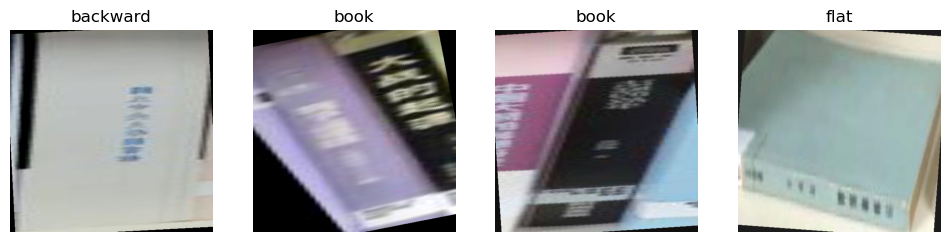

In [3]:
# Visualization of a Batch
def imshow(img, title):
    # Un-normalize for display
    mean = torch.tensor([0.485, 0.456, 0.406])
    std = torch.tensor([0.229, 0.224, 0.225])
    img = img * std[:, None, None] + mean[:, None, None]
    img = torch.clamp(img, 0, 1)
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.title(title)
    plt.axis('off')

# Get a batch
try:
    dataiter = iter(train_loader)
    images, labels = next(dataiter)

    # Show first 4 images
    plt.figure(figsize=(12, 4))
    for i in range(min(4, len(images))):
        ax = plt.subplot(1, 4, i + 1)
        label_name = train_dataset.classes[labels[i]]
        imshow(images[i], title=label_name)
    plt.show()
except Exception as e:
    print(f"Could not display batch: {e}")



## Model Architecture: PureCNN
We design a deep Convolutional Neural Network from scratch.
**Architecture Design Choice**:
- **Kernels**: We use 3x3 kernels which are standard for modern CNNs (like VGG) as they capture local patterns effectively with fewer parameters than larger kernels.
- **Pooling**: MaxPool2d (2x2) is used to reduce spatial dimensions by half at each stage.
- **Structure**: We stack 5 blocks of `Conv -> BN -> ReLU -> MaxPool`.
    - Input: 512x512
    - Block 1: -> 256x256 (32 filters)
    - Block 2: -> 128x128 (64 filters)
    - Block 3: -> 64x64 (128 filters)
    - Block 4: -> 32x32 (256 filters)
    - Block 5: -> 16x16 (512 filters)
- **Classifier**: We use **Adaptive Average Pooling** to reduce the 16x16 feature maps to 4x4. This drastically reduces the parameter count of the Fully Connected layer compared to flattening the whole 16x16 map.
    - Flatten: 512 * 4 * 4 = 8192 features.
    - FC Layers: 8192 -> 512 -> 4 (Logits).



In [4]:
class PureCNN(nn.Module):
    def __init__(self, num_classes=4):
        super(PureCNN, self).__init__()
        
        # Block 1
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        
        # Block 2
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        
        # Block 3
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        
        # Block 4
        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        
        # Block 5
        self.block5 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        
        # Classifier
        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4)) # Output: 512 x 4 x 4
        self.flatten = nn.Flatten()
        self.classifier = nn.Sequential(
            nn.Linear(512 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
        
    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.block5(x)
        
        x = self.adaptive_pool(x)
        x = self.flatten(x)
        x = self.classifier(x)
        return x

model = PureCNN(num_classes=4).to(DEVICE)
# Print model summary (optional, if torchsummary is installed, otherwise just print)
print(model)



PureCNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block4): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): Batc

In [5]:
# Training Setup
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# History tracking
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': []
}

best_val_acc = 0.0

print("Starting Training Loop...")

for epoch in range(NUM_EPOCHS):
    # Training Phase
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    epoch_train_loss = running_loss / len(train_loader)
    epoch_train_acc = 100 * correct / total
    
    # Validation Phase
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
            
    epoch_val_loss = val_loss / len(val_loader)
    epoch_val_acc = 100 * val_correct / val_total
    
    # Store history
    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_acc'].append(epoch_val_acc)
    
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
          f"Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.2f}%")
    
    # Checkpoint (Save Best Model)
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(f"-> Model saved with Val Acc: {best_val_acc:.2f}%")

print("Training Completed.")

# Release memory
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("GPU Memory Released")


Starting Training Loop...
Epoch [1/20] Train Loss: 0.8193 Acc: 72.80% | Val Loss: 0.7266 Acc: 77.30%
-> Model saved with Val Acc: 77.30%
Epoch [2/20] Train Loss: 0.3162 Acc: 89.57% | Val Loss: 0.4118 Acc: 87.73%
-> Model saved with Val Acc: 87.73%
Epoch [3/20] Train Loss: 0.2252 Acc: 92.36% | Val Loss: 0.2687 Acc: 92.02%
-> Model saved with Val Acc: 92.02%
Epoch [4/20] Train Loss: 0.2036 Acc: 93.21% | Val Loss: 0.1903 Acc: 92.64%
-> Model saved with Val Acc: 92.64%
Epoch [5/20] Train Loss: 0.2005 Acc: 93.26% | Val Loss: 0.1758 Acc: 95.71%
-> Model saved with Val Acc: 95.71%
Epoch [6/20] Train Loss: 0.1801 Acc: 93.68% | Val Loss: 0.4601 Acc: 92.64%
Epoch [7/20] Train Loss: 0.1787 Acc: 94.16% | Val Loss: 0.2720 Acc: 93.87%
Epoch [8/20] Train Loss: 0.1322 Acc: 95.28% | Val Loss: 0.3804 Acc: 93.25%
Epoch [9/20] Train Loss: 0.1487 Acc: 94.93% | Val Loss: 0.4560 Acc: 92.02%
Epoch [10/20] Train Loss: 0.1367 Acc: 95.22% | Val Loss: 0.2761 Acc: 93.25%
Epoch [11/20] Train Loss: 0.1452 Acc: 94.69

In [6]:
# Evaluation
print(f"Loading best model from {MODEL_SAVE_PATH}...")
model.load_state_dict(torch.load(MODEL_SAVE_PATH))
model.eval()

# Test Loop
test_correct = 0
test_total = 0
all_preds = []
all_labels = []

# For error analysis
errors = [] # (image, pred, actual)

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs_dev = inputs.to(DEVICE)
        labels_dev = labels.to(DEVICE)
        outputs = model(inputs_dev)
        _, predicted = torch.max(outputs.data, 1)
        
        test_total += labels.size(0)
        test_correct += (predicted == labels_dev).sum().item()
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())
        
        # Collect errors
        wrong_idx = (predicted != labels_dev).nonzero()
        for idx in wrong_idx:
            if len(errors) < 5: # Store first 5 errors
                idx = idx.item()
                # Store cpu copy for plotting
                errors.append((inputs[idx].cpu(), predicted[idx].item(), labels[idx].item()))

print(f"Test Accuracy: {100 * test_correct / test_total:.2f}%")



Loading best model from best_model.pth...


C:\Users\User\AppData\Local\Temp\ipykernel_32288\3131510858.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_SAVE_PATH))


Test Accuracy: 96.09%


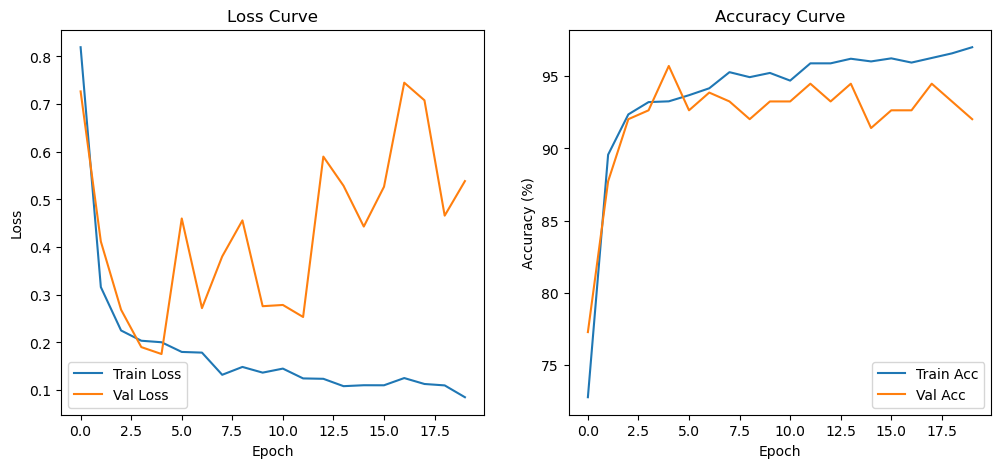

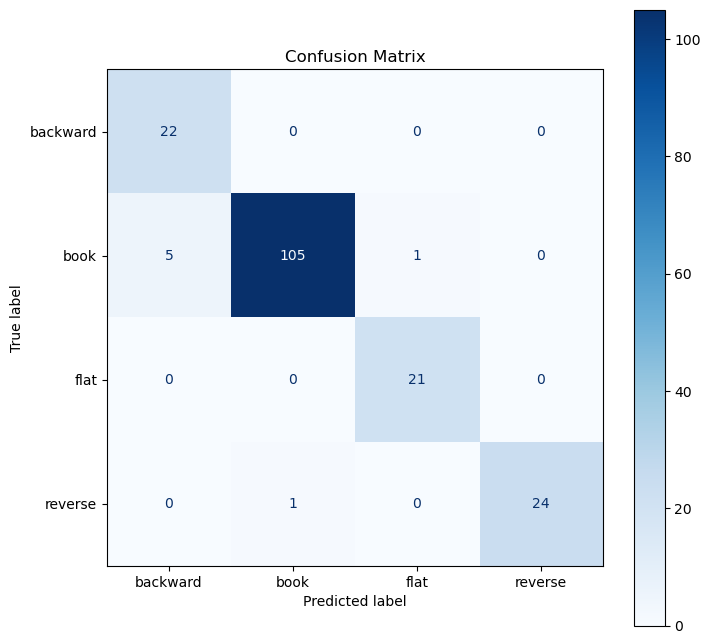

Error Analysis (Predicted vs Actual):


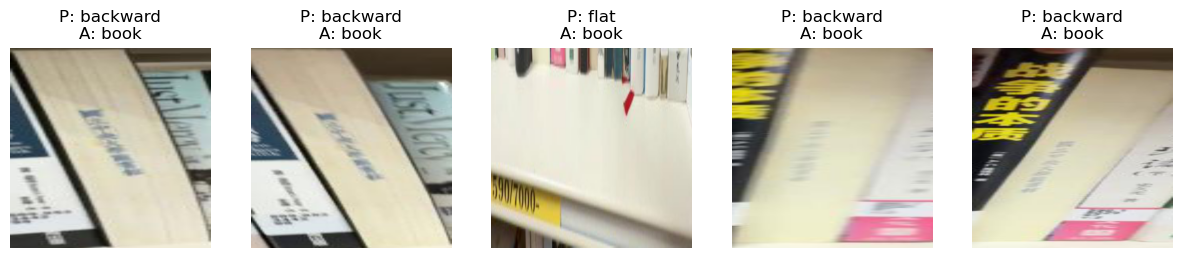

In [7]:
# Visualization Results
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.show()

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=train_dataset.classes)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Confusion Matrix")
plt.show()

# Error Analysis
if errors:
    print("Error Analysis (Predicted vs Actual):")
    plt.figure(figsize=(15, 5))
    for i, (img, pred, act) in enumerate(errors):
        ax = plt.subplot(1, 5, i + 1)
        title = f"P: {train_dataset.classes[pred]}\nA: {train_dataset.classes[act]}"
        imshow(img, title)
    plt.show()
else:
    print("No errors found in the captured batch!")

